这篇论文由 Qwen Team (阿里巴巴) 与 清华大学 LeapLab 的研究者联合完成，已被 NeurIPS 2025 接收。
- 论文从token熵（entropy）的全新视角出发，首次系统揭示了 RLVR（Reinforcement Learning with Verifiable Rewards，可验证奖励强化学习）提升大语言模型推理能力的内在机制，
  - 并提出了一个颠覆直觉的发现：<font color='red'>仅用 20% 的高熵"分叉token"进行策略梯度更新，不仅不损失性能，反而在更大模型上显著超越全token训练的效果。</font>

# 一、研究背景与核心问题
- 近年来，OpenAI o1、DeepSeek-R1、Kimi K1.5、Qwen3 等模型的推理能力飞跃，很大程度上归功于 RLVR——** 通过可自动验证的奖励信号（如数学题答案是否正确）** 来优化模型输出。
  - 然而，RLVR 的内在工作机制长期以来是一个"黑箱"：<font color='red'>现有方法直接对所有生成 token 一视同仁地进行策略梯度更新</font>，**却忽略了不同 token 在推理链条中扮演着截然不同的角色。**
- 作者提出了一个关键问题：
  - 在 Chain-of-Thought（CoT）推理过程中，不同 token 的生成不确定性（熵）分布有何规律？
  - 哪些 token 真正驱动了推理能力的提升？

# 二、核心发现：CoT 中的"80/20"熵分布
## 2.1 Token 熵的长尾分布
作者以 Qwen3-8B 为研究对象，在 AIME'24 和 AIME'25 上收集了超过 10⁶ 个生成 token，计算每个 token 的生成熵：

$H_t := - \sum_{j=1}^{V} p_{t,j} \log p_{t,j}$


- 其中$p_t = \pi_\theta(\cdot | q , o_{<t})$   是模型在当前上下文下的输出概率分布。

实验结果揭示了一个惊人的分布规律（见图2a）：
   
| 熵值范围                       | 占比      |
| -------------------------- | ------- |
| 熵 < 0.01                   | ~50.64% |
| 熵 > 0.672（80th percentile） | ~20%    |

也就是说，超过一半的 token 生成熵接近于零，**而仅有约 20% 的 token 表现出显著的高熵特征**。这是一个典型的长尾分布。

### 长尾分布（Long Tail Distribution）
- 是统计学、经济学和机器学习中的一个核心概念。
- 它描述的是一种“**少数头部占据大部分份额，而大量尾部个体占据小部分份额**”的数据分布形态。
  - 这个概念由 Chris Anderson 在 2004 年提出，最初用于描述互联网时代的商业和经济模式，后来在数据科学和深度学习中变得极其重要。

为了让你透彻理解，我们可以从以下几个维度来拆解：
#### 直观的形态特征
想象一条坐标轴，横轴是“物品的种类/频次排名”，纵轴是“出现的次数/销量”：
- 头部（Head）：最左边非常陡峭的高峰。代表极少数极其热门的、高频出现的事物（比如爆款商品、常用词汇）。
- **长尾（Long Tail）**： <font color='red'>向右延伸的、极其平缓且漫长的曲线。代表数量极其庞大、但每个单独出现频率极低的事物。</font>

- 核心反直觉点：虽然长尾中的每一个个体销量都很低，但因为它们的种类（数量）极其庞大，当把这些微小的份额累加起来时，其总和往往能够与“头部”的总和相媲美，甚至超过头部。

#### 经典的生活案例
- 商业与电商：
  - 线下书店只能摆最畅销的几千本书（头部）；而亚马逊可以卖几千万种书，那些极其冷门、一年只卖几本的专业书籍（长尾），汇聚起来创造了巨大的利润。
- 自然语言处理（NLP）：
  - 在语言模型中，像“的”、“是”、“我”这样的词出现频率极高（头部）；而大量的生僻词、专业术语、人名地名（长尾）出现极少，但种类占了词表的大头。

#### <font color='red'>为什么长尾分布对深度学习是个“大麻烦”？</font>
在人工智能领域，长尾分布通常被称为长尾问题（Long-tail Problem）或类别不平衡（Class Imbalance），它是训练大模型时的一大痛点：
- 头部过拟合：
  - 模型在训练时，会频繁看到头部的数据，**导致模型对常见事物的预测非常准，甚至“死记硬背”了这些样本。**
- <font color='red'>尾部欠拟合：</font>
  - 长尾数据因为太罕见，模型在训练时可能只见过一两次，甚至没见过。这导致模型对罕见事物的识别能力极差。
- 灾难性后果：
  - 在自动驾驶中，常见的“汽车”、“行人”是头部，但极其罕见的“侧翻的卡车”、“穿着奇装异服的人”是长尾。**如果模型学不好长尾，就会在真实世界中引发严重的安全事故。**
#### 如何解决长尾问题？

为了让模型在长尾数据上也表现良好，工业界和学术界通常会采取以下策略：
- 数据层面：
  - 过采样（Oversampling）：
    - **把长尾的罕见样本复制多份，或者通过数据增强（如图像翻转、文本同义词替换）“造”出更多长尾样本。**
  - 欠采样（Undersampling）：
    - **减少头部样本的数量，让模型不要过度关注头部。**
- 算法层面：
  - 重新加权（Re-weighting）：<font color='red'>在计算交叉熵损失时，给长尾样本更高的权重（Loss Weight），强迫模型“重视”它们。</font>
  - 解耦训练（Decoupled Training）：**先用全量数据训练一个基础模型，然后再专门用长尾数据对模型的最后一层（分类头）进行微调。**
  
- 大模型时代的解法：
正如你之前问到的中期训练（Mid-Training），** 大模型通过在预训练阶段尽可能多地“见”各种长尾知识（哪怕只见过一次），** 并在中期训练阶段通过高质量数据强化这些长尾逻辑，从而极大地提升了模型对罕见事物的泛化能力。

##  2.2 高熵 Token = "分叉点"（Forking Tokens）
通过词云分析（图2b、2c），作者进一步发现：
-  高熵 token
  - （如 wait, however, unless, since, because, thus, suppose, assume, given, define）<font color='red'>在语义上充当逻辑连接器和推理转折点，它们决定了模型接下来走向哪条推理分支。</font>
- 低熵 token
  - （如词缀、代码片段、数学符号）则主要用于完成当前语言结构或数学表达式，确定性极高。
  
作者将这些高熵 token 命名为 <font color='red'>"分叉 token"（forking tokens）</font>，因为它们就像推理路径上的岔路口，引导模型探索不同的推理方向。

## 2.3 定量验证：温度调控实验
为了验证分叉 token 的关键作用，作者设计了一个精巧的温度分离实验：对高熵 token 和低熵 token 分别施加不同的解码温度 T ：

$
T'_t = \begin{cases} 
T_{\text{high}} & \text{if } H_t > h_{\text{threshold}} \\ 
T_{\text{low}} & \text{otherwise} 
\end{cases}
$

结果（图3）显示：
- 提高$ T_{high}$（增加分叉 token 的熵）→ 推理性能显著提升，AIME 得分从 68.33 提升至 72.22。
- 降低 $T_{high}$（压制分叉 token 的熵）→ **性能显著下降至 62.71。**
- <font color='red'>改变 $T_{low}$对性能影响很小，甚至过高会导致模型生成无意义内容。</font>

**这定量确认了高熵 token 作为推理"决策点"的核心地位。**


# RLVR 训练中的熵演化规律
## 3.1 RLVR 保留基础模型的熵模式
作者追踪了 DAPO 算法在 Qwen3-14B 上训练过程中 token 熵的演化：
- 位置稳定性：
  - 即使在训练收敛时（step 1360），当前模型与基础模型在前 20% 高熵 token 位置上的重叠率仍 超过 86%（表1）。这说明 RLVR 并未创造新的决策点，而是在基础模型已建立的推理框架内进行精细化。
- 幅度选择性：
  - 初始熵越高的 token，在 RLVR 后熵的增加幅度越大；低熵 token 的熵变化极小（图4）。RLVR 主要放大现有分叉点的不确定性，鼓励探索通往正确答案的替代路径。
  
### 高熵 token 并不会随着训练的进行而显著降低其“位置”或“重要性”
- <font color='red'>高熵 token 的“位置”具有高度稳定性：</font>
  - ** 这些 token 并非随机出现，而是集中在推理过程中的关键决策点（即“分叉词元”），** 
    - 它们决定了模型走向哪条推理路径。即使模型经过大量训练，这些“岔路口”依然存在，只是模型在这些位置上的预测概率分布发生了变化（比如从犹豫变得更自信，或从错误路径转向正确路径）。
- 高熵 token 的“熵值”可能下降，但“角色”不变：
  - 训练过程中，模型会逐渐学会在这些关键位置上做出更准确的预测，因此这些位置的熵值（不确定性）可能会降低。但它们作为“决策点”的本质没有改变——它们依然是模型需要“思考”和“选择”的地方，**而不是像低熵 token 那样只是机械地补全语言结构。**
- 为什么重叠率这么高？
  - <font color='red'>这是因为 RLVR 训练的目标不是消除不确定性，而是优化不确定性。</font> **模型在学习如何更好地处理这些高熵位置，而不是避开它们。**
    - 换句话说，<font color='red'>训练让模型在这些关键点上“更聪明”，而不是“更确定”。</font>这也解释了为什么只训练这 20% 的高熵 token 就能达到甚至超越全量训练的效果——**因为它们才是真正驱动推理能力提升的核心**。

## 3.2 训练过程中的熵百分位动态
图5展示了不同熵百分位在训练中的变化：
- 高百分位（80th-100th）：熵明显上升，说明模型在关键决策点保持了探索性。
- 低百分位（0th-40th）：熵几乎不变，说明语言流畅性相关的 token 未被干扰。


# 方法：Forking Token 掩码策略
基于以上发现，作者提出了一个极简但极其有效的改进：
- <font color='red'>在 RLVR 中，仅对前 20% 高熵 token 计算策略梯度，将其余 80% 低熵 token 的梯度置零（mask）。</font>

- 以 DAPO 为基线算法，修改后的目标函数只在高熵位置$ t∈T_{fork}$ 上计算：

In [2]:
from IPython.display import Image

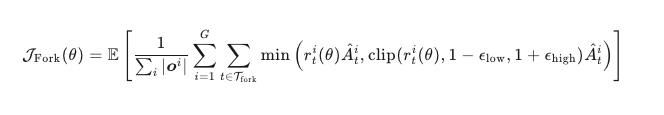

In [3]:
Image(filename='./Image/dapo.png')

# 五、实验结果：超越 80/20 法则
## 5.1 主实验：惊人的 Scaling Trend
在 Qwen3 系列基础模型上，对比"全 token DAPO"与"仅前 20% 高熵 token DAPO"：

| 模型        | 方法       | AIME'24          | AIME'25           |
| --------- | -------- | ---------------- | ----------------- |
| Qwen3-8B  | 全 token  | 33.3             | 25.4              |
| Qwen3-8B  | **仅 20% 高熵** | 34.6             | 26.2              |
| Qwen3-14B | 全 token  | 50.4             | 38.1              |
| Qwen3-14B | **仅 20% 高熵** | **55.8** (+5.21) | **42.9** (+4.79)  |
| Qwen3-32B | 全 token  | 55.8             | 45.6              |
| Qwen3-32B | **仅 20% 高熵** | **63.5** (+7.71) | **56.7** (+11.04) |

### 关键结论：
- Qwen3-8B：
  - 仅 20% token 即可达到与全 token 相当的性能。
- Qwen3-14B 和 32B：
  - 仅 20% token 显著超越全 token 训练，且模型越大，收益越显著。
- **32B 模型在 20k 最大长度下达到 63.5 (AIME'24) 和 56.7 (AIME'25)，创下 < 600B 参数基础模型直接 RLVR 训练的 SoTA。扩展到 29k 长度后，AIME'24 进一步提升至 68.1。**

##  反向验证：低熵 token 有害
作为对照，作者仅对后 80% 低熵 token进行训练：
- 性能显著下降，**证明低熵 token 不仅无益，甚至可能阻碍推理学习。**


##  比例消融实验
改变保留的高熵 token 比例：
- 10%：移除部分有用的分叉 token，探索不足，性能下降。
- 50% 或 100%：引入低熵 token，同样削弱探索效率，性能下降。
- 20% 左右是最佳平衡点，既能保留有效探索，又避免低熵 token 的干扰。


# 深入讨论
- 6.1 为什么 RL 比 SFT 泛化更好？
  - RL：**保持或增加分叉 token 的熵，维持灵活的推理路径，使模型能够泛化到未见过的问题。**
  - SFT：通过模仿学习降低 token 熵，导致模型记忆固定推理模板，泛化能力差。
- 6.2 LLM 推理 vs. 传统 RL
  - 传统 RL：通常假设动作空间中的熵是均匀的。
  - LLM CoT：具有混合熵结构——大部分 token 需要低熵以保证语言可读性，少数关键 token 需要高熵以驱动推理探索。这种结构源于预训练语言模型的先验知识和生成可读文本的需求。
- 6.3 Clip-Higher 的优势
**DAPO 中的 clip-higher 机制（对高比率设置更宽松的裁剪上限）被证明优于传统的统一熵奖励：**
  - 统一熵奖励会无差别地提升所有 token 的熵，破坏低熵 token 的语言结构。
  - <font color='red'>clip-higher 选择性地提升高熵 token 的熵，在不损害语言流畅性的前提下增强推理探索。</font>

# 论文贡献总结
- 首次从 token 熵视角系统分析 RLVR：
  - 揭示了 CoT 推理中"少数高熵 token 决定推理方向"的核心规律。
- 提出 Forking Token 概念：
  - 将高熵 token 定义为推理路径的"分叉点"，并通过温度实验定量验证其关键作用。
- 发现 RLVR 的熵演化机制：
  - RLVR 主要保留并放大基础模型已有的高熵模式，而非重构熵景观。
- 提出极简高效的训练策略：
  - 仅更新 20% 高熵 token 即可达到或超越全 token 训练，且随模型规模增大收益递增。
- 刷新 SoTA：Qwen3-32B 在 AIME 上创下 <600B 参数基础模型 RLVR 训练的新纪录。

# 实践意义
这篇论文的发现对 LLM 推理训练具有深远的实践价值：
- 训练效率：仅优化 20% token 可大幅减少计算开销，同时提升性能。
- 算法设计：为 RLVR 算法提供了"**选择性优化**"的新范式，启发未来研究关注 token 级别的异质性。
- 模型规模：揭示了高熵 token 策略的强 scaling 特性，**越大模型越能从中受益**。
- 工程落地：该策略已被集成到开源训练框架（如 ms-swift）中，可通过 top_entropy_quantile=0.2 参数直接启用。

### 总的来说，
- 这篇论文以优雅的实验设计和深刻的理论洞察，揭示了 RLVR 提升 LLM 推理能力的本质：真正重要的不是全部 token，而是那 20% 站在推理岔路口的高熵"分叉 token"。
- 这一发现不仅超越了经典的 80/20 法则，更为未来高效、可扩展的推理模型训练指明了方向。